# T-TEST APLICADO A LA MINERÍA

El T-test se usa para validar si un cambio operativo realmente produjo un efecto o si la diferencia que vemos en los datos podría ser solo ruido del proceso.

## Recordando

### 1. Que es el T-TEST:
El t-test se usa para evaluar si la media de una variable cambió entre dos condiciones.
Ejemplos en planta:
* Vibración antes y después de cambiar un impulsor
* Vibración antes y después de mantenimiento
* Consumo eléctrico antes y después de modificar un setpoint

El objetivo es saber si el cambio observado es real o podría ser azar.

### 2. Tipo de T-TEST importantes
#### Paired t-test
Se usa cuando se compara el mismo equipo en dos momentos distintos..
Ejemplo:
* Vibración de una bomba antes y después del mantenimiento.
Cada medición está emparejada con la misma máquina.

#### Independent t-test
Se usa cuando se compara dos grupos independientes.
Ejemplo:
* Consumo de energía con estrategia de control A vs estrategia B
* Recuperación metalúrgica con reactivo antiguo vs reactivo nuevo
Aquí los grupos no están emparejados.

### 3. Supuestos importantes del T-TEST
Los datos deberían: 
* Ser numéricos
* Tener observaciones aproximadamente independientes
* Tener una distribución aproximadamente normal

### 4. Varianza iguales (homocedasticidad)
El t-test clásico asume que las varianzas son iguales.

Esto se puede evaluar con Levene test.

Pero en la práctica muchos analistas usan Welch t-test, porque:

* no requiere varianzas iguales
* es más robusto


### 5. Que significa el p-value
El p-value mide la evidencia contra la hipótesis de que no hubo cambio.

Regla común:

* p ≤ 0.05 → hay evidencia de cambio

* p > 0.05 → no hay evidencia suficiente

Importante:
el p-value no indica cuánto cambió la variable, solo indica si el cambio es estadísticamente detectable.

### 6. Problema con grandes volumentes de datos
Cuando hay muchísimos datos, incluso cambios muy pequeños pueden producir p-values muy pequeños.

Por eso es importante revisar también:

* Magnitud del cambio (tamaño del efecto)
* Impacto operacional

### 7. Diferencia entre T_TEST y regresión

1. T-test: evalúa si dos condiciones tienen medias diferentes

2. Regresión múltiple: analiza cómo varias variables influyen en una variable objetivo

    Ejemplo en planta:

    analizar cómo afectan a la vibración:

    * caudal
    * densidad de pulpa
    * rpm de la bomba
    * corriente del motor

## Evitar cometer los siguientes errores

### 1. Autocorrelación (datos no independientes)
Los sensores registran datos continuamente:

* Vibración
* Presión
* Caudal
* Corriente

Ejemplo de vibración cada segundo: 4.10, 4.12, 4.11, 4.13, 4.12

Cada valor depende mucho del anterior.
Esto se llama autocorrelación temporal.

Problema:

Muchos análisis estadísticos asumen independencia, pero en sensores eso casi nunca se cumple.

Por eso aplicar directamente:
* t-test
* correlaciones simples
puede dar conclusiones engañosas.

En la práctica se suele:
* agregar datos (promedio por minuto, hora, turno)
* usar modelos de series temporales

### 2. Cambios operacionales que contaminan el analisis
En una planta las condiciones cambian constantemente:

* carga del molino
* densidad de pulpa
* mineral diferente
* ajustes de operador

Ejemplo:

la vibración aumenta, pero no por falla, sino porque:

* el caudal subió
* la densidad cambió

Si no controlas estas variables, puedes concluir algo incorrecto.

Por eso en ciencia de datos industrial se usan modelos como:
* regresión múltiple
*   modelos multivariables

### 3. Muchísimos datos genera p-values engañosos
Los historiadores de planta pueden tener:

* millones de registros

Con tantos datos, incluso diferencias muy pequeñas producen:

p-values muy pequeños

Eso hace que muchos análisis concluyan “hay una diferencia significativa”

cuando en realidad no tiene impacto operativo.

Por eso siempre se revisa:
* magnitud del cambio
* impacto en operación

### 4. Sensores con ruido o mala calidad de datos
En planta es común encontrar:

* sensores descalibrados
* valores congelados
* spikes
* datos faltantes

el data cleaning en industria suele consumir 70-80% del trabajo.

### 5. Confundir correlación con causalidad

Ejemplo: la vibración aumenta cuando aumenta el caudal, pero eso no significa que el caudal cause la vibración.

Podría ser que:

* mayor carga del molino
* mayor densidad
* mayor desgaste

En minería muchas variables están correlacionadas entre sí.

Por eso se necesita:
* Conocimiento del proceso
* análisis multivariable

#### Realizarse las siguientes preguntas

Antes de modelar, siempre pregunta:

1. ¿Los datos tienen autocorrelación?
2. ¿Las variables del proceso están interactuando?
3. ¿Hay ruido o errores de sensores?
4. ¿El resultado tiene impacto operacional real?

# PROYECTO: Evaluación de un nuevo aceite en los pads del molino SAG usando T-Test

Contexto operacional.

En una concentradora se probó un nuevo aceite lubricante para los pads del molino SAG.

El área de mantenimiento quiere saber:

**¿El nuevo aceite reduce la temperatura promedio de los pads del molino?**

La temperatura es crítica porque:
* temperaturas altas → degradación del aceite
* mayor fricción → desgaste del pad
* riesgo de parada del molino

### Variable de estudio.
* Para este caso consideraremos analizar la temperatura del PAD en °C (simulado). Estos datos provendran el PI System.
* La frecuencia de medición del sensor es de 1 dato por minuto, lo cual genera 525600 registros.
* Para este caso de analisis y asegurar un nivel alto de independencia de los datos, realizaremos el promedio por hora, lo cual nos dará 8750 datos por año.

### Conclusiones iniciales
1. Tenemos dos grupos de datos. Temperatura con el antiguo aceite y temperatura con el nuevo aceite
2. El T_TEST que usaremos es el **Independent T-TEST** ya que se tiene dos grupo de dato.

## 1. Simulación de los datos de operación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)  # For reproducibility

#Simulación 6 meses de datos por minuto
n = 262800

#Temperatura con aceite antiguo
temp_old = np.random.normal(loc=52, scale=1.8, size=n//2)

#Temperatura con aceite nuevo (ligeramente menor)
temp_new = np.random.normal(loc=50.8, scale=1.7, size=n//2)

data = pd.DataFrame({
    "Temperature": np.concatenate([temp_old, temp_new]),
    "oil_type": ["old"]*(n//2) + ["new"]*(n//2)
})

data.tail()

,Temperature,oil_type
262795,50.712981,new
262796,47.061882,new
262797,52.190916,new
262798,51.764963,new
262799,50.712964,new


## 2. Convertir datos por minuto a promedio por hora

In [3]:
data['timestamp'] = pd.date_range(start='2025-01-01',
                                 periods=len(data),
                                 freq='min')

In [4]:
hourly_data = (data.set_index('timestamp')
               .groupby('oil_type')
               .resample('h')
               .mean()
               .reset_index()
               )

hourly_data

,oil_type,timestamp,Temperature
0,new,2025-04-02 06:00:00,51.136626
1,new,2025-04-02 07:00:00,50.919993
2,new,2025-04-02 08:00:00,50.391443
3,new,2025-04-02 09:00:00,50.469778
4,new,2025-04-02 10:00:00,50.740082
...,...,...,...
4375,old,2025-04-02 01:00:00,52.392676
4376,old,2025-04-02 02:00:00,52.215953
4377,old,2025-04-02 03:00:00,52.051565
4378,old,2025-04-02 04:00:00,51.677203


# 3. Exploración de los datos (EDA)

In [5]:
hourly_data.groupby("oil_type")["Temperature"].describe()

,count,mean,std,min,25%,50%,75%,max
oil_type,,,,,,,,
new,2190.0,50.797907,0.216056,50.144653,50.651187,50.798458,50.944582,51.50534
old,2190.0,52.002681,0.236720,51.168752,51.848040,51.999745,52.159710,52.93382


* La media para el aceite nuevo es de 50.79 y para el aceite antiguo es de 52, esto nos da un indiio de que el aceite nuevo podría estar mejor
* La desviación estandar o variabilidad de losdatos en ambos aceites es casi similar, par el nuevo es de 0.21 y para el antiguo 0.23, lo puede indicar que el proceso es de comportamiento normal.
* Los percentiles indican que aparentemente los datos tienen una distribución normal

La pregunta operacional era: **"¿El nuevo aceite reduce la temperatura de los PADS?**

Teniendo en cuenta que H₀ siempre representa “no hay efecto” o “no hay cambio” entonces:
* la hipotesis nula H0: **"El nuevo aceite no cambia la temperatura de los PADS"**
* La hpotesis alterna H1: **"El nuevo aceite reduce la temperatura"**

In [6]:
#Revisión de tipos de datos y valores faltantes
hourly_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   oil_type     4380 non-null   str           
 1   timestamp    4380 non-null   datetime64[us]
 2   Temperature  4380 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 102.8 KB


In [7]:
#Revisión de la cantidad de registros por tipo de aceite
hourly_data['oil_type'].value_counts()


oil_type
new    2190
old    2190
Name: count, dtype: int64

In [8]:
#Revisión de valores faltantes
hourly_data.isna().sum()

oil_type       0
timestamp      0
Temperature    0
dtype: int64

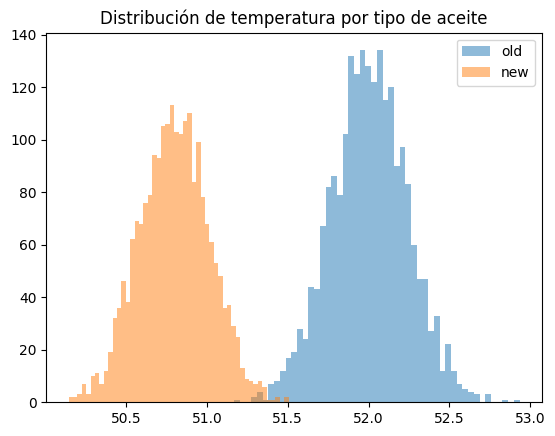

In [9]:
#Visualización
for oil in ['old', 'new']:
    subset = hourly_data[hourly_data['oil_type'] == oil]
    plt.hist(subset['Temperature'], bins=50, alpha=0.5, label=oil)

plt.legend()
plt.title('Distribución de temperatura por tipo de aceite')
plt.show()

La distribución indica que no estan tan sobrepuestas, es muy ligero, lo cual indica que probablemente el nuevo aceitereduzca las vibraciones considerablemente signficativo.

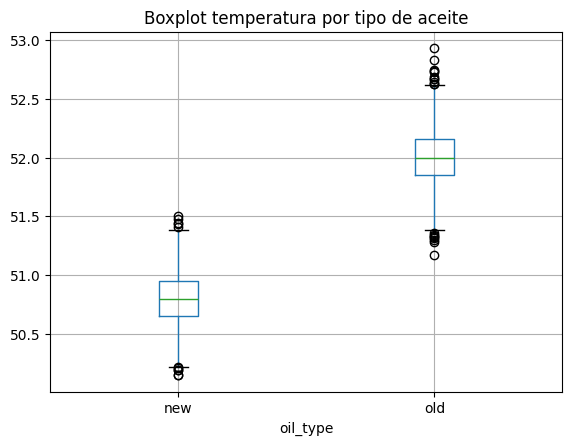

In [10]:
# boxplot
hourly_data.boxplot(column='Temperature', by='oil_type')
plt.title('Boxplot temperatura por tipo de aceite')
plt.suptitle('')
plt.show()

Se puede observar valores extremos, esto puede significar errores de sensor, eventos operacionales u otras fallas puntuales.

# 4. Aplicando el T-test

In [11]:
#Preparación de los datos para el test
old = hourly_data[hourly_data['oil_type'] == 'old']['Temperature']
new = hourly_data[hourly_data['oil_type'] == 'new']['Temperature']

Esperamos un p-value pequeño porque:

* la media del aceite antiguo ≈ 52°C
* la media del aceite nuevo ≈ 50.8°C
* hay una diferencia consistente (~1.2°C)
* y además tenemos muchos datos (alta potencia estadística)

**Entonces el test detectará esa diferencia como estadísticamente significativa**

Recuerda: El p-value depende de:

* tamaño de la diferencia
* variabilidad
* cantidad de datos

In [12]:
#aplicando T-Test (Welch's t-test  que no asume varianzas iguales)
from scipy.stats import ttest_ind
stat, p_value = ttest_ind(old, new, equal_var=False)
print(f"'p-value:', {p_value:.10f}")


'p-value:', 0.0000000000


**Rechazamos la H0 ya que es menor a 0.05, lo que infica que existe una evidencia muy fuerte de que el nuevo aceite si cambia la temperatura y la reduce**


# 5. Complementos para la toma de decisión

El resultado anterior no es suficiente para tomar una decision, el t-test reponde 'Hay diferencia?', pero no responde 'Vale la pena?'

## 5.1 Falta tener conocimiento de:
* Vida util del aceite
* desgaste de los PADS
* Frecuencia de fallas (MTBF)
* costos

con esto estamos concluyendo que el problema involucra negocios + confiabilidad, no solo estadistica. Para entender esto simularemos estos datos

## 5.2 Simulación de fallas, costos, vida util del aceite, mantenimiento.
A. Aceite antiguo:
* MTBF = 4000 horas
* costo de aceite = 100 USD
* costos por falla = 50000 USD

B. Aceite nuevo
* MTBF = 6000 horas
* Costo de aceite = 130 USD
* Costo por falla = 50000 USD

In [13]:
# Simulación de fallas usando Wiebull
np.random.seed(42)
# Parámetros de la distribución de Weibull (forma, escala)
shape = 2 #desgaste tipico
scale_old = 4000
scale_new = 6000

In [14]:
np.random.seed(42)

n_sim = 1000

cost_failure = 50000
cost_oil_old = 100
cost_oil_new = 130

results_old = []
results_new = []

for _ in range(n_sim):
    
    #Simulación de tiempos hasta la falla
    failures_old = np.random.weibull(2, 1000) * scale_old #MTBF con aceite antiguo
    failures_new = np.random.weibull(2, 1000) * scale_new #MTBF con aceite nuevo
    
    def count_failures(failure_times):
        total = 0
        time = 0
        count = 0
        
        for t in failure_times:
            time += t
            if time > 8760:
                break
            count += 1
        
        return count
    
    fail_old = count_failures(failures_old)
    fail_new = count_failures(failures_new)
    
    cost_old = fail_old * cost_failure + cost_oil_old
    cost_new = fail_new * cost_failure + cost_oil_new
    
    results_old.append(cost_old)
    results_new.append(cost_new)

print("Costo promedio old:", np.mean(results_old))
print("Costo promedio new:", np.mean(results_new))

Costo promedio old: 108600.0
Costo promedio new: 65580.0


En nuevo aceite reduce el costo anual en 43020 USD, esto es una reducción de aproximadamente 40%.

CONCLUSIÓN PREVIA:
* Aunque el aceite nuevo es más caro, reduce significativamente la frecuencia de fallas, lo que disminuye el costo total de operación.
* El uso del nuevo aceite permite reducir el corto anual en aproximadamente 40%, debido a la disminución en la frecuencia de fallas, se recomienda su implementación, sujeto a validación operativa.

### RIESGO POR CAMBIO DE ACEITE
Ahora queremos responder ¿Que tan riesgoso es cambiar al nuevo aceite?


In [ ]:
#probabilidad de que el nuevo aceite sea peor
results_old = np.array(results_old)
results_new = np.array(results_new)

prob_new_worse = np.mean(results_new > results_old)

print("Probabilidad de que el nuevo aceite sea más caro:", prob_new_worse)

Probabilidad de que el nuevo aceite sea más caro: 0.366


Tenemos un riesgo de 36.6% de 

### IMPACTO ECONÓMICO CUANDO FALLA LA DECISIÓN

In [16]:
# diferencia de costos
diff = results_new - results_old

# solo cuando el nuevo es peor
loss_when_worse = diff[diff > 0]

print("Costo promedio cuando el nuevo es peor:", np.mean(loss_when_worse))
print("Peor caso:", np.max(loss_when_worse))

Costo promedio cuando el nuevo es peor: 17106.50273224044
Peor caso: 150030


* Probabilidad de que el nuevo sea peor → 36.6%
* Pérdida promedio cuando es peor → ~17,106 USD
* Peor caso → 150,030 USD
* Ahorro promedio total → ~43,020 USD

#### CONCLUSIÓN FINAL:
**El nuevo aceite presenta un ahorro promedio significativo (~43k USD/año). Sin embargo, existe una probabilidad del 36.6% de incurrir en mayores costos, con una pérdida promedio de ~17k USD y un peor escenario de ~150k USD. Se recomienda su implementación controlada, acompañada de monitoreo continuo para mitigar riesgos.**